In [1]:
import numpy as np
import pandas as pd
import datasets
import torch
import torch.nn as nn
import os
import transformers
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
import lightning as L
import random
def set_random_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


set_random_seed(42)
L.seed_everything(42)

/home/jupyter/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jupyter/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
Seed set to 42


42

In [3]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Частоиспользуемые функции:

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

def plot_r2_function(y_true, preds, dir_to_save=None):
    r2 = r2_score(y_true, preds)
    fig = plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=preds, alpha=0.6)
    plt.plot([min(y_true), max(y_true)],
             [min(y_true), max(y_true)],
             color='red', linestyle='--', linewidth=1)
    plt.title(f"Scatter plot: True vs Predicted values\n$R^2$ = {r2:.3f}", fontsize=14)
    plt.xlabel("True values", fontsize=12)
    plt.ylabel("Predicted values", fontsize=12)
    plt.grid(True, alpha=0.3)
    if dir_to_save is not None:
        plt.savefig(dir_to_save, dpi=300, bbox_inches='tight')
    plt.show()

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    return {"rmse": np.sqrt(mean_squared_error(labels, predictions))}

def plot_preds_vs_true_histplots(preds, y_true, preds_label="Predictions", true_label="True values", dir_to_save=None):
    sns.set_style("ticks")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    xlabel = "Values"
    ylabel = "Counts"

    sns.histplot(preds, kde=True, color="blue", label=preds_label, alpha=0.6, ax=axes[0])
    axes[0].set_title("Distribution Predicted values", fontsize=14)
    axes[0].set_xlabel(xlabel, fontsize=12)
    axes[0].set_ylabel(ylabel, fontsize=12)
    axes[0].legend(fontsize=12)

    sns.histplot(preds, kde=True, color="blue", label=preds_label, alpha=0.5, ax=axes[1])
    sns.histplot(y_true, kde=True, color="red", label=true_label, alpha=0.5,  ax=axes[1])
    axes[1].set_title("True vs Predicted values distribution", fontsize=14)
    axes[1].set_xlabel(xlabel, fontsize=12)
    axes[1].set_ylabel(ylabel, fontsize=12)
    axes[1].legend(fontsize=12)

    sns.histplot(y_true, kde=True, color="red", label=true_label, alpha=0.6, ax=axes[2])
    axes[2].set_title("Distribution True values", fontsize=14)
    axes[2].set_xlabel(xlabel, fontsize=12)
    axes[2].set_ylabel(ylabel, fontsize=12)
    axes[2].legend(fontsize=12)

    plt.tight_layout()

    if dir_to_save is not None:
        plt.savefig(dir_to_save, dpi=300, bbox_inches='tight')
    plt.show()

Автоматические параметры эксперимента:

In [6]:
path_dir_models = '/home/jupyter/datasphere/project/Models/'

In [7]:
model_n_to_save = '21'

learning_rate_frozen = 5e-3
learning_rate_fine_tuning = 5e-4
epochs_frozen = 10
epochs_fine_tuning = 30

for dir in ['transfer learning plots','after learning plots']:
  dir_to_create_path = path_dir_models + model_n_to_save + '/' + dir
  os.makedirs(dir_to_create_path, exist_ok=True)

#Загрузка и подготовка датасета

In [8]:
df_prime_dataset = pd.read_csv('/home/jupyter/datasphere/project/BERT project/PRIME_Dataset.csv')
#df_sppa_dataset['seq_truncated'] = df_sppa_dataset['sequence'].str[-250:-49]
df_prime_dataset

,gene_id,mean,log_mean,sequence,motif_id
0,AT1G01010,244.885832,2.388964,ACATTTCAAACCACTTGTTCTCTTTTATGTTTTGGTAAGAGCTATC...,"['AT3G22760', 'AT1G51140', 'AT2G42280', 'AT1G3..."
1,AT1G01020,367.643741,2.565427,ATCGGATATGACATAGCGGATTTTGTATATCTTTAGAGAGTATGAG...,"['AT3G57920', 'AT3G61120', 'AT2G45650', 'AT4G1..."
2,AT1G01030,116.788171,2.067399,TATATAATTTTGATTGAAATTGATGTATACAGCGCAGATGATTTTT...,"['AT4G30080', 'AT4G35550', 'AT4G38000', 'AT4G0..."
3,AT1G01040,2077.279230,3.317495,GTGAGGTCCATGTCCACAATAAGAAATCAAATACCAAACAAAGTAT...,"['AT5G13790', 'AT5G10140', 'AT5G15800', 'AT4G1..."
4,AT1G01050,1543.546080,3.188520,CTTGTGGACCGCTCATCCTGTGGCTCAAATACACCTTCAGGGAGTG...,"['AT3G46070', 'AT1G51600', 'AT2G38090', 'AT2G3..."
...,...,...,...,...,...
21180,AT5G67590,1907.232462,3.280404,ATCTTATCCAAACTACAAAAACAGACAATAGCGCAAGATCAAATCT...,"['AT1G70000', 'AT1G74840', 'AT5G08520', 'AT5G0..."
21181,AT5G67600,981.665750,2.991964,CAACAAACCAAACTATGTTTGATTATACAGCATCCATATCCCTGAA...,"['AT3G30210', 'AT1G13450', 'AT1G02065', 'AT4G1..."
21182,AT5G67610,512.790922,2.709940,GATCCTTAATTTTAGTTCTAGTTGTGACATGATGAATAAGATATTT...,"['AT3G25990', 'AT1G32510', 'AT5G18090', 'AT2G3..."
21183,AT5G67620,44.770289,1.650990,TGATATGTATGATTAGGATGTTGAACTCGGATTTATGTTTTTTTTT...,"['AT2G22430', 'AT2G18350', 'AT1G69180', 'AT4G3..."


In [9]:
texts = df_prime_dataset['motif_id'].map(eval)
df = pd.DataFrame(texts)
df['len'] = df['motif_id'].str.len()
df['motif_id'] = df['motif_id'].map(' '.join)
df

,motif_id,len
0,AT3G22760 AT1G51140 AT2G42280 AT1G35460 AT1G51...,367
1,AT3G57920 AT3G61120 AT2G45650 AT4G18960 AT2G38...,411
2,AT4G30080 AT4G35550 AT4G38000 AT4G01280 AT1G49...,425
3,AT5G13790 AT5G10140 AT5G15800 AT4G18960 AT3G54...,352
4,AT3G46070 AT1G51600 AT2G38090 AT2G38090 AT4G38...,249
...,...,...
21180,AT1G70000 AT1G74840 AT5G08520 AT5G03150 AT5G67...,266
21181,AT3G30210 AT1G13450 AT1G02065 AT4G14770 AT3G24...,367
21182,AT3G25990 AT1G32510 AT5G18090 AT2G38090 AT1G18...,428
21183,AT2G22430 AT2G18350 AT1G69180 AT4G37790 AT3G24...,412


In [10]:
df_prime_dataset['log_mean'] = df_prime_dataset['log_mean'] - df_prime_dataset['log_mean'].min()

In [8]:
#df_sppa_dataset = df_sppa_dataset.iloc[0:12000]

In [11]:
from sklearn.model_selection import train_test_split

x_train, x, y_train, y = train_test_split(df_prime_dataset['sequence'], df_prime_dataset['log_mean'],
                                          train_size=0.7, shuffle=True,
                                          random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x, y,
                                                train_size=0.4, shuffle=True,
                                                random_state=42)

<Axes: ylabel='Count'>

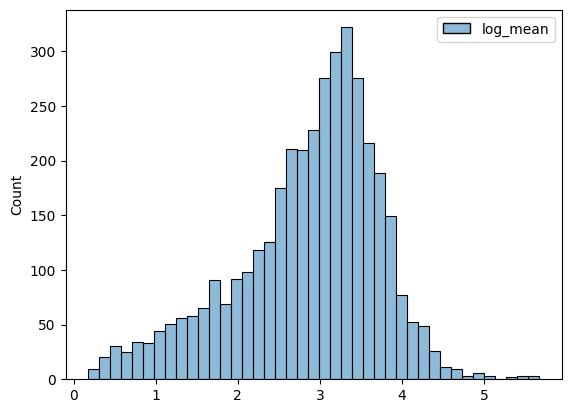

In [12]:
sns.histplot([y_train, y_val, y_test])

In [13]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()
y_train_norm = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_norm = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_norm = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

<Axes: ylabel='Count'>

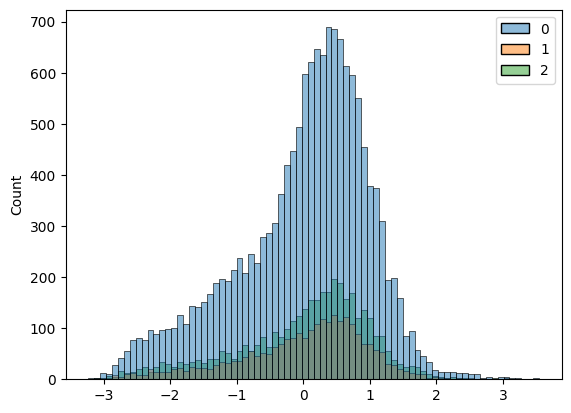

In [14]:
sns.histplot([y_train_norm, y_val_norm, y_test_norm])

In [13]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-athaliana')

In [15]:
train_in = tokenizer(x_train.tolist(), padding=True, truncation=True, max_length=512, return_tensors="pt")
val_in = tokenizer(x_val.tolist(), padding=True, truncation=True, max_length=512, return_tensors="pt")
test_in = tokenizer(x_test.tolist(), padding=True, truncation=True, max_length=512, return_tensors="pt")

In [16]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(
    train_in['input_ids'],
    train_in['attention_mask'],
    torch.FloatTensor(y_train.values)
)
val_ds = TensorDataset(
    val_in['input_ids'],
    val_in['attention_mask'],
    torch.FloatTensor(y_val.values)
)
test_ds = TensorDataset(
    test_in['input_ids'],
    test_in['attention_mask'],
    torch.FloatTensor(y_test.values)
)

In [17]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=64, num_workers=4)

In [19]:
y_true = np.array([float(item) for _, _, target in iter(train_loader) for item in target])

#Загрузка архитектуры предобученной модели арабидопсиса

In [18]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-athaliana')
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-athaliana', trust_remote_code=True)
model

A new version of the following files was downloaded from https://huggingface.co/AIRI-Institute/gena-lm-bert-base-athaliana:
- modeling_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
2025-10-08 14:14:42.551393: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 14:14:47.631377: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-08 14:14:51.172964: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:3

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=3)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (pre_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (post_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              (softmax): Sof

#1. Замена последних слоев на регрессию

In [19]:
gena_module_name = model.__class__.__module__
print(gena_module_name)

transformers_modules.AIRI-Institute.gena-lm-bert-base-athaliana.293a2e4ed543cb9094a8e6cc112dccf80b7d2a57.modeling_bert


In [20]:
import importlib
# available class names:
# - BertModel, BertForPreTraining, BertForMaskedLM, BertForNextSentencePrediction,
# - BertForSequenceClassification, BertForMultipleChoice, BertForTokenClassification,
# - BertForQuestionAnswering
# check https://huggingface.co/docs/transformers/model_doc/bert
cls = getattr(importlib.import_module(gena_module_name), 'BertForSequenceClassification')
cls

transformers_modules.AIRI-Institute.gena-lm-bert-base-athaliana.293a2e4ed543cb9094a8e6cc112dccf80b7d2a57.modeling_bert.BertForSequenceClassification

In [21]:
model = cls.from_pretrained(
    'AIRI-Institute/gena-lm-bert-base-t2t', num_labels=1, problem_type="regression"
)
model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at AIRI-Institute/gena-lm-bert-base-t2t and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=3)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (pre_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (post_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              

In [24]:
model.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.GELU(), 
            nn.Dropout(0.1),
            nn.Linear(256, 1, bias=True)
        )
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=3)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (pre_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (post_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              

# 2. Обучение модели

Lightning

In [22]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torchmetrics import MeanMetric, Accuracy
import math
from torchmetrics import MetricCollection
from torchmetrics.regression import (
    MeanSquaredError,
    MeanAbsoluteError,
    R2Score,
    ExplainedVariance,
    PearsonCorrCoef,
    SpearmanCorrCoef,
    MeanSquaredLogError,
    CosineSimilarity
)


class Pipeline(L.LightningModule):
    def __init__(
        self,
        model,
        exp_name="baseline",
        criterion=nn.MSELoss(),
        optimizer_class=torch.optim.AdamW,
        optimizer_kwargs={"lr": 1e-4, "weight_decay": 0.01},
        warmup_steps=1000,
        total_steps=None
    ) -> None:
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.total_steps = total_steps
        self.optimizer_class = optimizer_class
        self.optimizer_kwargs = optimizer_kwargs
        self.warmup_steps = warmup_steps
        metrics = MetricCollection({
            'mse': MeanSquaredError(),
            'rmse': MeanSquaredError(squared=False),  # RMSE
            'mae': MeanAbsoluteError(),
            'r2': R2Score(),
            'explained_variance': ExplainedVariance(),
            'pearson': PearsonCorrCoef(),
            'spearman': SpearmanCorrCoef(),
        })
        self.train_metrics = metrics.clone(postfix="/train")
        self.valid_metrics = metrics.clone(postfix="/val")
        self.test_metrics = metrics.clone(postfix="/test")
        
        self.save_hyperparameters(ignore=['model', 'criterion'])


    def configure_optimizers(self):
            optimizer = self.optimizer_class(
                self.model.parameters(), **self.optimizer_kwargs
            )

            # Если total_steps не задан, вычисляем автоматически
            if self.total_steps is None and self.trainer is not None:
                self.total_steps = self.trainer.estimated_stepping_batches

            if self.total_steps:
                scheduler = get_cosine_schedule_with_warmup(
                    optimizer,
                    num_warmup_steps=self.warmup_steps,
                    num_training_steps=self.total_steps,
                    num_cycles=0.5  # Для cosine annealing
                )

                return {
                    "optimizer": optimizer,
                    "lr_scheduler": {
                        "scheduler": scheduler,
                        "interval": "step",
                        "frequency": 1,
                    },
                }
            else:
                return optimizer

    def training_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch
        out = self.model(input_ids, attention_mask)
        loss = self.criterion(out['logits'].squeeze(), labels)
        self.log("Loss/train", loss, prog_bar=True)
        self.train_metrics.update(out['logits'].squeeze(), labels)
        return loss

    def validation_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch
        out = self.model(input_ids, attention_mask)
        loss = self.criterion(out['logits'].squeeze(), labels)
        self.log("Loss/val", loss, prog_bar=True)
        self.valid_metrics.update(out['logits'].squeeze(), labels)
        print("\nПримеры предсказаний:")
        for i in range(5):
            print(f"True: {labels[i].item():.3f} | Pred: {out['logits'].squeeze()[i].item():.3f}")

    def test_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch
        out = self.model(input_ids, attention_mask)
        self.test_metrics.update(out['logits'].squeeze(), labels)

    def on_training_epoch_end(self):
        train_metrics = self.train_metrics.compute()
        self.log("train_r2", train_metrics['r2/train'], prog_bar=True)
        self.log("train_rmse", train_metrics['rmse/train'], prog_bar=True)
        self.log_dict(train_metrics)
        self.train_metrics.reset()

    def on_validation_epoch_end(self):
        valid_metrics = self.valid_metrics.compute()
        self.log("val_r2", valid_metrics['r2/val'], prog_bar=True)
        self.log("val_rmse", valid_metrics['rmse/val'], prog_bar=True)
        self.log_dict(valid_metrics)
        self.valid_metrics.reset()

    def on_test_epoch_end(self):
        test_metrics = self.test_metrics.compute()
        self.log_dict(test_metrics, sync_dist=True)
        self.test_metrics.reset()
        
        
        self._log_metrics_analysis(test_metrics, "test")

    def _log_metrics_analysis(self, metrics, stage):
        """Анализ и логирование метрик"""
        analysis_text = f"""
        {stage.upper()} METRICS ANALYSIS:
        • R²: {metrics[f'r2/{stage}']:.4f} (ближе к 1.0 = лучше)
        • RMSE: {metrics[f'rmse/{stage}']:.4f} (в тех же единицах что и target)
        • MAE: {metrics[f'mae/{stage}']:.4f} (средняя абсолютная ошибка)
        • Pearson: {metrics[f'pearson/{stage}']:.4f} (линейная корреляция)
        • Spearman: {metrics[f'spearman/{stage}']:.4f} (ранговая корреляция)
        """
        
        # Логируем в TensorBoard
        self.logger.experiment.add_text(
            f"{stage}_metrics_analysis/epoch_{self.current_epoch}",
            f"```\n{analysis_text}\n```",
            self.current_epoch
        )

In [23]:
for name, param in model.named_parameters():
    print(name, "\t", param.requires_grad)

bert.embeddings.word_embeddings.weight 	 True
bert.embeddings.position_embeddings.weight 	 True
bert.embeddings.token_type_embeddings.weight 	 True
bert.embeddings.LayerNorm.weight 	 True
bert.embeddings.LayerNorm.bias 	 True
bert.encoder.layer.0.pre_attention_ln.weight 	 True
bert.encoder.layer.0.pre_attention_ln.bias 	 True
bert.encoder.layer.0.post_attention_ln.weight 	 True
bert.encoder.layer.0.post_attention_ln.bias 	 True
bert.encoder.layer.0.attention.self.query.weight 	 True
bert.encoder.layer.0.attention.self.query.bias 	 True
bert.encoder.layer.0.attention.self.key.weight 	 True
bert.encoder.layer.0.attention.self.key.bias 	 True
bert.encoder.layer.0.attention.self.value.weight 	 True
bert.encoder.layer.0.attention.self.value.bias 	 True
bert.encoder.layer.0.attention.output.dense.weight 	 True
bert.encoder.layer.0.attention.output.dense.bias 	 True
bert.encoder.layer.0.intermediate.dense.weight 	 True
bert.encoder.layer.0.intermediate.dense.bias 	 True
bert.encoder.layer.0.o

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger

model.train()
exp_name = f'{model_n_to_save}'
logger = TensorBoardLogger(save_dir=path_dir_models + model_n_to_save + '/logs/', name=exp_name)

pipeline = Pipeline(
    model=model,
    exp_name=exp_name,
    optimizer_class=AdamW,
    optimizer_kwargs={"lr": learning_rate_fine_tuning, "weight_decay": 0.01},
    warmup_steps=1000,
)

checkpoint_callback = ModelCheckpoint(
    monitor="Loss/val", mode="min", filename="best"
)

trainer = Trainer(
        max_epochs=epochs_fine_tuning,
        callbacks=[checkpoint_callback],
        log_every_n_steps=10,
        logger=logger,
    )

trainer.fit(
    model=pipeline,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

/home/jupyter/.local/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name          | Type                          | Params | Mode 
------------------------------------------------------------------------
0 | model  

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/jupyter/.local/lib/python3.10/site-packages/transformers/modeling_utils.py:1742: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(



Примеры предсказаний:
True: 2.920 | Pred: -0.239
True: 3.757 | Pred: -0.280
True: 3.203 | Pred: -0.266
True: 3.105 | Pred: -0.242
True: 2.760 | Pred: -0.287
Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:10<00:10,  0.09it/s]
Примеры предсказаний:
True: 4.037 | Pred: -0.271
True: 1.132 | Pred: -0.248
True: 1.014 | Pred: -0.282
True: 3.105 | Pred: -0.290
True: 4.327 | Pred: -0.268
Epoch 0: 100%|██████████| 232/232 [06:03<00:00,  0.64it/s, v_num=0, Loss/train=0.950]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/40 [00:00<?, ?it/s]
Примеры предсказаний:
True: 2.920 | Pred: 2.829
True: 3.757 | Pred: 2.829
True: 3.203 | Pred: 2.828
True: 3.105 | Pred: 2.829
True: 2.760 | Pred: 2.829

Validation DataLoader 0:   2%|▎         | 1/40 [00:00<00:21,  1.80it/s]
Примеры предсказаний:
True: 4.037 | Pred: 2.829
True: 1.132 | Pred: 2.829
True: 1.014 | Pred: 2.829
True: 3.105 | Pred: 2.829
True: 4.327 | Pred: 2.829

Validation DataLoader 0:   5%|▌    

/home/jupyter/.local/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32). Setting the correlation coefficient to nan.
  warnings.warn(*args, **kwargs)


...

Epoch 4: 100%|██████████| 232/232 [05:43<00:00,  0.68it/s, v_num=0, Loss/train=0.593, Loss/val=0.782, val_r2=-0.00308, val_rmse=0.885]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/40 [00:00<?, ?it/s]
Примеры предсказаний:
True: 2.920 | Pred: 2.780
True: 3.757 | Pred: 2.780
True: 3.203 | Pred: 2.780
True: 3.105 | Pred: 2.780
True: 2.760 | Pred: 2.780

Validation DataLoader 0:   2%|▎         | 1/40 [00:00<00:21,  1.81it/s]
Примеры предсказаний:
True: 4.037 | Pred: 2.780
True: 1.132 | Pred: 2.780
True: 1.014 | Pred: 2.780
True: 3.105 | Pred: 2.780
True: 4.327 | Pred: 2.780

Validation DataLoader 0:   5%|▌         | 2/40 [00:01<00:21,  1.75it/s]
Примеры предсказаний:
True: 3.970 | Pred: 2.780
True: 3.684 | Pred: 2.780
True: 2.413 | Pred: 2.780
True: 3.679 | Pred: 2.780
True: 2.839 | Pred: 2.780

Validation DataLoader 0:   8%|▊         | 3/40 [00:01<00:21,  1.75it/s]
Примеры предсказаний:
True: 2.869 | Pred: 2.780
True: 2.257 | Pred: 2.780
True: 

/home/jupyter/.local/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32). Setting the correlation coefficient to nan.
  warnings.warn(*args, **kwargs)


Epoch 5: 100%|██████████| 232/232 [05:43<00:00,  0.68it/s, v_num=0, Loss/train=0.642, Loss/val=0.786, val_r2=-0.00761, val_rmse=0.887]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/40 [00:00<?, ?it/s]
Примеры предсказаний:
True: 2.920 | Pred: 2.847
True: 3.757 | Pred: 2.847
True: 3.203 | Pred: 2.847
True: 3.105 | Pred: 2.847
True: 2.760 | Pred: 2.847

Validation DataLoader 0:   2%|▎         | 1/40 [00:00<00:21,  1.80it/s]
Примеры предсказаний:
True: 4.037 | Pred: 2.847
True: 1.132 | Pred: 2.847
True: 1.014 | Pred: 2.847
True: 3.105 | Pred: 2.847
True: 4.327 | Pred: 2.847

Validation DataLoader 0:   5%|▌         | 2/40 [00:01<00:21,  1.75it/s]
Примеры предсказаний:
True: 3.970 | Pred: 2.847
True: 3.684 | Pred: 2.847
True: 2.413 | Pred: 2.847
True: 3.679 | Pred: 2.847
True: 2.839 | Pred: 2.847

Validation DataLoader 0:   8%|▊         | 3/40 [00:01<00:21,  1.76it/s]
Примеры предсказаний:
True: 2.869 | Pred: 2.847
True: 2.257 | Pred: 2.847
True: 

/home/jupyter/.local/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The variance of predictions or target is close to zero. This can cause instability in Pearson correlationcoefficient, leading to wrong results. Consider re-scaling the input if possible or computing using alarger dtype (currently using torch.float32). Setting the correlation coefficient to nan.
  warnings.warn(*args, **kwargs)


Epoch 6:  58%|█████▊    | 134/232 [03:15<02:23,  0.68it/s, v_num=0, Loss/train=0.688, Loss/val=0.780, val_r2=-0.000141, val_rmse=0.883]

In [ ]:
'''from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

checkpoint_callback = ModelCheckpoint(
    monitor="MeanSquaredError/val", mode="min", filename="best"
)

exp_name = f'{model_n_to_save}'
logger = TensorBoardLogger(save_dir=path_dir_models + model_n_to_save + '/logs/', name=exp_name)

trainer = Trainer(
    max_epochs=epochs_fine_tuning,
    callbacks=[checkpoint_callback],
    num_sanity_val_steps=1,
    log_every_n_steps=100,
    logger=logger,
)

pipeline = Pipeline(
    model=model,
    exp_name=exp_name,
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": learning_rate_fine_tuning},
)

trainer.fit(
    model=pipeline,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)
'''

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                          | Params | Mode 
------------------------------------------------------------------------
0 | model         | BertForSequenceClassification | 110 M  | eval 
1 | criterion     | MSELoss                       | 0      | train
2 | train_metrics | MetricCollection              | 0      | train
3 | valid_metrics | MetricCollection              | 0      | train
4 | test_metrics  | MetricCollection              | 0      | train
----------------

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/home/jupyter/.local/lib/python3.10/site-packages/transformers/modeling_utils.py:1742: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(



Примеры предсказаний:
True: 0.495 | Pred: 0.007
True: -1.191 | Pred: 0.008
True: -0.023 | Pred: -0.009
True: -0.586 | Pred: 0.011
True: -0.236 | Pred: -0.001
Epoch 0: 100%|██████████| 1854/1854 [03:20<00:00,  9.26it/s, v_num=0, Loss/train=0.607] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/318 [00:00<?, ?it/s]
Примеры предсказаний:
True: 0.495 | Pred: -0.036
True: -1.191 | Pred: -0.036
True: -0.023 | Pred: -0.036
True: -0.586 | Pred: -0.036
True: -0.236 | Pred: -0.036

Validation DataLoader 0:   0%|          | 1/318 [00:00<00:08, 37.06it/s]
Примеры предсказаний:
True: -2.172 | Pred: -0.036
True: -0.099 | Pred: -0.036
True: 1.166 | Pred: -0.036
True: 0.228 | Pred: -0.036
True: 0.645 | Pred: -0.036

Validation DataLoader 0:   1%|          | 2/318 [00:00<00:08, 35.16it/s]
Примеры предсказаний:
True: -1.422 | Pred: -0.036
True: 0.896 | Pred: -0.036
True: -2.380 | Pred: -0.036
True: -0.515 | Pred: -0.036
True: -1.297 | Pred: -0.036

Validation 

In [26]:
trainer.test(
    model=pipeline, dataloaders=test_loader, verbose=True, ckpt_path="best"
)

Restoring states from the checkpoint path at /home/jupyter/datasphere/project/Models/15/logs/15/version_3/checkpoints/best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/jupyter/datasphere/project/Models/15/logs/15/version_3/checkpoints/best.ckpt
/home/jupyter/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 477/477 [00:14<00:00, 33.93it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   MeanSquaredError/test   │    0.9934705495834351     │
└───────────────────────────┴───────────────────────────┘

[{'MeanSquaredError/test': 0.9934705495834351}]

## Заморозка модели

In [22]:
for param in model.parameters():
    param.requires_grad = False

##Дообучение последних слоев

In [ ]:
model.bert.pooler.dense.weight.requires_grad = True
model.bert.pooler.dense.bias.requires_grad = True
model.classifier.weight.requires_grad = True
model.classifier.bias.requires_grad = True

In [23]:
for name, param in model.named_parameters():
    print(name, "\t", param.requires_grad)

bert.embeddings.word_embeddings.weight 	 False
bert.embeddings.position_embeddings.weight 	 False
bert.embeddings.token_type_embeddings.weight 	 False
bert.embeddings.LayerNorm.weight 	 False
bert.embeddings.LayerNorm.bias 	 False
bert.encoder.layer.0.pre_attention_ln.weight 	 False
bert.encoder.layer.0.pre_attention_ln.bias 	 False
bert.encoder.layer.0.post_attention_ln.weight 	 False
bert.encoder.layer.0.post_attention_ln.bias 	 False
bert.encoder.layer.0.attention.self.query.weight 	 False
bert.encoder.layer.0.attention.self.query.bias 	 False
bert.encoder.layer.0.attention.self.key.weight 	 False
bert.encoder.layer.0.attention.self.key.bias 	 False
bert.encoder.layer.0.attention.self.value.weight 	 False
bert.encoder.layer.0.attention.self.value.bias 	 False
bert.encoder.layer.0.attention.output.dense.weight 	 False
bert.encoder.layer.0.attention.output.dense.bias 	 False
bert.encoder.layer.0.intermediate.dense.weight 	 False
bert.encoder.layer.0.intermediate.dense.bias 	 False
ber

In [ ]:
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate_frozen)
criterion = nn.MSELoss()

# 6. Функция для вычисления метрик
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask) # .squeeze()
            loss = criterion(outputs['logits'].squeeze(), labels)
            total_loss += loss.item()
    return total_loss / len(dataloader)

# 7. Цикл обучения с диагностикой
for epoch in range(epochs_frozen):
    model.train()
    train_loss = 0

    # Включаем прогресс-бар
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}')

    for batch_idx, batch in enumerate(progress_bar):
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(input_ids, attention_mask)#.squeeze()
        #print(outputs['logits'].squeeze())
        #print(labels)
        loss = criterion(outputs['logits'].squeeze(), labels)

        # Обратный проход
        loss.backward()

        # Диагностика градиентов (добавьте в любой момент)
        if batch_idx == 0:  # Проверяем первый батч
            grads = []
            for name, param in model.named_parameters():
                if param.grad is not None:
                    grads.append(param.grad.abs().mean().item())
            print(f"\nСредний градиент: {np.mean(grads):.2e}")

        # Шаг оптимизации
        optimizer.step()

        train_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    # Валидация
    val_loss = evaluate(model, val_loader)
    print(f'Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}')

    # Проверка предсказаний (первые 5 примеров)
    model.eval()
    with torch.no_grad():
        sample = next(iter(val_loader))
        preds = model(sample[0].to(device), sample[1].to(device))['logits'].squeeze()
        print("\nПримеры предсказаний:")
        for i in range(5):
            print(f"True: {sample[2][i].item():.3f} | Pred: {preds[i].item():.3f}")

Epoch 1:   0%|          | 0/1854 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1773: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
Epoch 1:   0%|          | 1/1854 [00:00<29:56,  1.03it/s, loss=1.39]


Средний градиент: 8.53e-02


Epoch 1: 100%|██████████| 1854/1854 [00:44<00:00, 41.68it/s, loss=0.942]


Epoch 1 | Train Loss: 1.0375 | Val Loss: 0.9740

Примеры предсказаний:
True: 0.495 | Pred: -0.105
True: -1.191 | Pred: -0.106
True: -0.023 | Pred: -0.106
True: -0.586 | Pred: -0.106
True: -0.236 | Pred: -0.106


Epoch 2:   0%|          | 5/1854 [00:00<00:42, 43.05it/s, loss=1.16] 

...

Epoch 29 | Train Loss: 0.9780 | Val Loss: 0.9068

Примеры предсказаний:
True: 0.495 | Pred: 0.130
True: -1.191 | Pred: -0.006
True: -0.023 | Pred: 0.130
True: -0.586 | Pred: -0.274
True: -0.236 | Pred: 0.121


Epoch 30:   0%|          | 5/1854 [00:00<00:42, 43.80it/s, loss=1.84]


Средний градиент: 3.40e-01


Epoch 30: 100%|██████████| 1854/1854 [00:43<00:00, 42.63it/s, loss=1.25]


Epoch 30 | Train Loss: 0.9726 | Val Loss: 0.9106

Примеры предсказаний:
True: 0.495 | Pred: 0.178
True: -1.191 | Pred: -0.189
True: -0.023 | Pred: 0.178
True: -0.586 | Pred: -0.219
True: -0.236 | Pred: 0.178


In [ ]:
preds = []
with torch.no_grad():
    for batch in tqdm(train_loader):
        input_ids, attention_mask, labels = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        predictions = outputs.logits.squeeze(-1)
        preds.extend(predictions.cpu().numpy())

  0%|          | 0/875 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1773: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 875/875 [00:18<00:00, 47.81it/s]


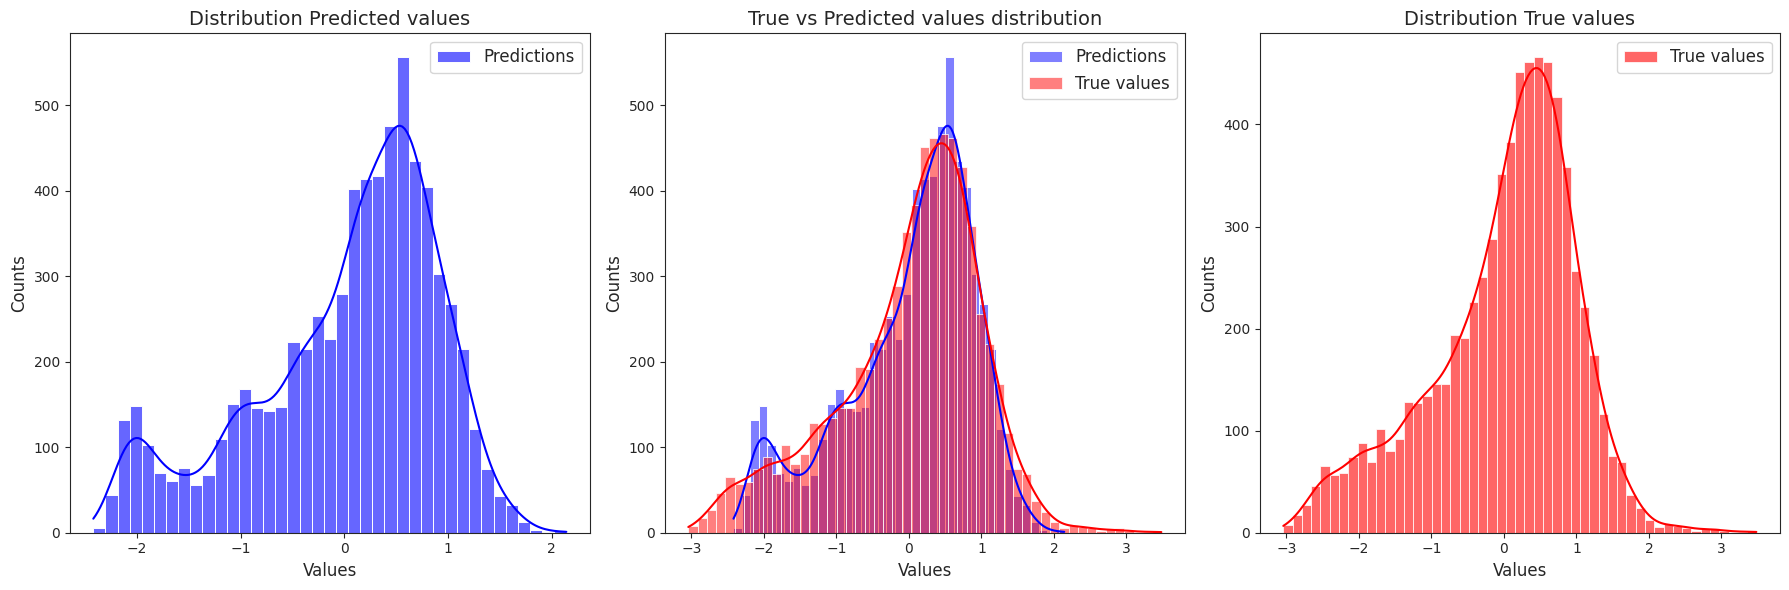

In [ ]:
path_hist_plots = '/content/drive/MyDrive/Нейронные сети и машинное обучение/Проект/Модель/' + model_n_to_save + '/transfer learning plots/train_hist_tf.png'
plot_preds_vs_true_histplots(preds, y_true, preds_label="Predictions", true_label="True values", dir_to_save=path_hist_plots)

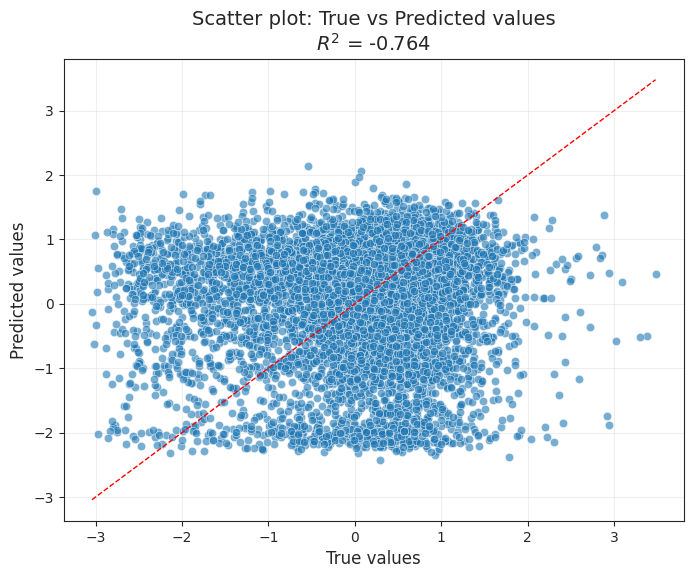

In [ ]:
path_r2_plots = '/content/drive/MyDrive/Нейронные сети и машинное обучение/Проект/Модель/' + model_n_to_save + '/transfer learning plots/train_r2_tf.png'
plot_r2_function(y_true, preds, dir_to_save=path_r2_plots)

##Разморозка всей модели и дообучение - Fine Tuning

In [24]:
for name, param in model.named_parameters():
    param.requires_grad = True
    print(name, "\t", param.requires_grad)

bert.embeddings.word_embeddings.weight 	 True
bert.embeddings.position_embeddings.weight 	 True
bert.embeddings.token_type_embeddings.weight 	 True
bert.embeddings.LayerNorm.weight 	 True
bert.embeddings.LayerNorm.bias 	 True
bert.encoder.layer.0.pre_attention_ln.weight 	 True
bert.encoder.layer.0.pre_attention_ln.bias 	 True
bert.encoder.layer.0.post_attention_ln.weight 	 True
bert.encoder.layer.0.post_attention_ln.bias 	 True
bert.encoder.layer.0.attention.self.query.weight 	 True
bert.encoder.layer.0.attention.self.query.bias 	 True
bert.encoder.layer.0.attention.self.key.weight 	 True
bert.encoder.layer.0.attention.self.key.bias 	 True
bert.encoder.layer.0.attention.self.value.weight 	 True
bert.encoder.layer.0.attention.self.value.bias 	 True
bert.encoder.layer.0.attention.output.dense.weight 	 True
bert.encoder.layer.0.attention.output.dense.bias 	 True
bert.encoder.layer.0.intermediate.dense.weight 	 True
bert.encoder.layer.0.intermediate.dense.bias 	 True
bert.encoder.layer.0.o

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate_fine_tuning)
criterion = nn.MSELoss()

# 6. Функция для вычисления метрик
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask) # .squeeze()
            loss = criterion(outputs['logits'].squeeze(), labels)
            total_loss += loss.item()
    return total_loss / len(dataloader)

# 7. Цикл обучения с диагностикой
for epoch in range(epochs_fine_tuning):
    model.train()
    train_loss = 0

    # Включаем прогресс-бар
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}')

    for batch_idx, batch in enumerate(progress_bar):
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(input_ids, attention_mask)#.squeeze()
        #print(outputs['logits'].squeeze())
        #print(labels)
        loss = criterion(outputs['logits'].squeeze(), labels)

        # Обратный проход
        loss.backward()

        # Диагностика градиентов (добавьте в любой момент)
        if batch_idx == 0:  # Проверяем первый батч
            grads = []
            for name, param in model.named_parameters():
                if param.grad is not None:
                    grads.append(param.grad.abs().mean().item())
            print(f"\nСредний градиент: {np.mean(grads):.2e}")

        # Шаг оптимизации
        optimizer.step()

        train_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    # Валидация
    val_loss = evaluate(model, val_loader)
    print(f'Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}')

    # Проверка предсказаний (первые 5 примеров)
    model.eval()
    with torch.no_grad():
        sample = next(iter(val_loader))
        preds = model(sample[0].to(device), sample[1].to(device))['logits'].squeeze()
        print("\nПримеры предсказаний:")
        for i in range(5):
            print(f"True: {sample[2][i].item():.3f} | Pred: {preds[i].item():.3f}")

Epoch 1:   0%|          | 0/1050 [00:00<?, ?it/s]/home/jupyter/.local/lib/python3.10/site-packages/transformers/modeling_utils.py:1742: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(



Средний градиент: 7.07e-03


Epoch 1: 100%|██████████| 1050/1050 [03:22<00:00,  5.19it/s, loss=1.54] 


Epoch 1 | Train Loss: 1.0497 | Val Loss: 0.9853

Примеры предсказаний:
True: 0.510 | Pred: -0.021
True: 0.780 | Pred: -0.021
True: -2.739 | Pred: -0.021
True: -1.320 | Pred: -0.021
True: -0.345 | Pred: -0.021


Epoch 2:   0%|          | 1/1050 [00:00<03:34,  4.89it/s, loss=1.53]


Средний градиент: 1.36e-02


Epoch 2:  14%|█▍        | 151/1050 [00:28<02:48,  5.32it/s, loss=1.49] 

In [ ]:
preds = []
with torch.no_grad():
    for batch in tqdm(train_loader):
        input_ids, attention_mask, labels = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        predictions = outputs.logits.squeeze(-1)
        preds.extend(predictions.cpu().numpy())
plot_r2_function(y_true, preds, dir_to_save=None)

# 3. Сохранение результатов дообучения модели

In [ ]:
output_dir = path_dir_models + model_n_to_save + '/'
model.save_pretrained(output_dir)

# 5. Загрузка и тестирование модели после загрузки с диска

In [61]:
gena_module_name = 'transformers_modules.AIRI-Institute.gena-lm-bert-base-athaliana.1d8d32a6227e64c1aab6fa01b872e56950f67bc9.modeling_bert'
import importlib
# available class names:
# - BertModel, BertForPreTraining, BertForMaskedLM, BertForNextSentencePrediction,
# - BertForSequenceClassification, BertForMultipleChoice, BertForTokenClassification,
# - BertForQuestionAnswering
# check https://huggingface.co/docs/transformers/model_doc/bert
cls = getattr(importlib.import_module(gena_module_name), 'BertForSequenceClassification')
cls

transformers_modules.AIRI-Institute.gena-lm-bert-base-athaliana.1d8d32a6227e64c1aab6fa01b872e56950f67bc9.modeling_bert.BertForSequenceClassification

In [66]:
output_dir = path_dir_models +'15/'

# Загрузка модели и токенизатора
model = cls.from_pretrained(output_dir)
#tokenizer = AutoTokenizer.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-athaliana')

model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=3)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (pre_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (post_attention_ln): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              

Через Dataloader test

In [67]:
preds = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids, attention_mask, labels = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        predictions = outputs.logits.squeeze(-1)
        preds.extend(predictions.cpu().numpy())

  0%|          | 0/68 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:1773: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 68/68 [00:05<00:00, 12.67it/s]


In [68]:
y_true = np.array([float(item) for _, _, target in iter(test_loader) for item in target])

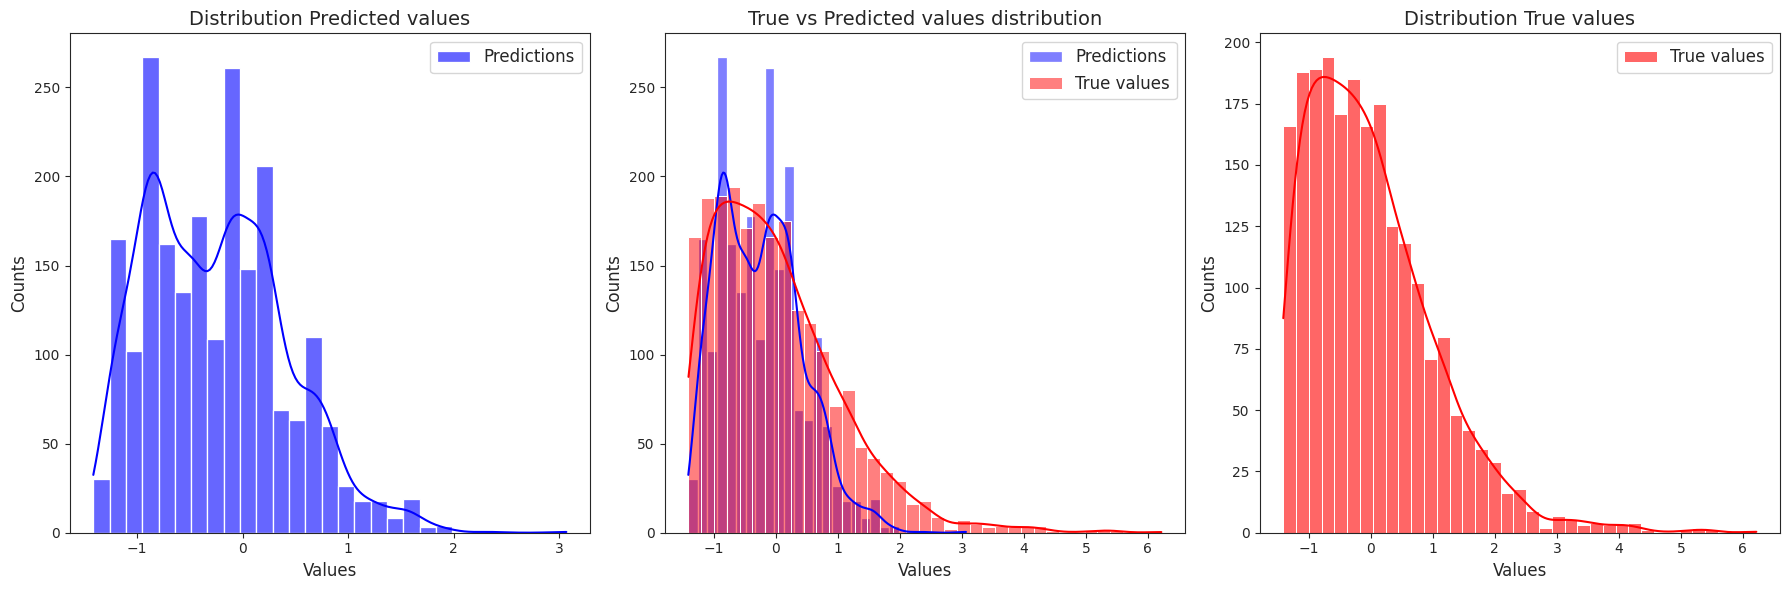

In [69]:
path_hist_plots = path_dir_models + model_n_to_save + '/after learning plots/test_hist.png'
plot_preds_vs_true_histplots(preds, y_true, preds_label="Predictions", true_label="True values", dir_to_save=path_hist_plots)

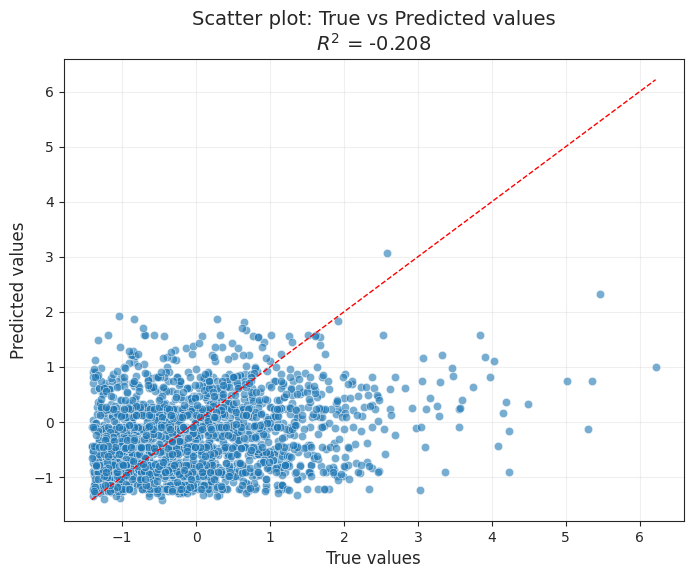

{'rmse': np.float64(1.1361527914116583)}

In [70]:
path_r2_plots = path_dir_models + model_n_to_save + '/after learning plots/test_r2.png'
plot_r2_function(y_true, preds, dir_to_save=path_r2_plots)
compute_metrics((y_true, preds))